# Predictive Monitoring - BPI Challenge 2017

**Content**

1. [Data Exploration and Preparation](#1.-Data-Exploration-and-Preparation)
2. [Event Log Enrichment](#2.-Event-Log-Enrichment)
3. [Prefix Extraction](#3.-Prefix-Extraction)
   - [Train/Test Split](#Train/Test-Split)
   - [Prefix Extraction with Time Cutoff](#Prefix-Extraction-with-Time-Cutoff)
   - [Prefix Extraction with Fixed Prefix Length](#Prefix-Extraction-with-Fixed-Prefix-Length)
   - [Determine Prefix Extraction Variant To Analyze](#Determine-Prefix-Extraction-Variant-To-Analyze)
4. [Feature Encoding](#4.-Feature-Encoding)
5. [Model Training](#5.-Model-Training)
6. [Evaluation](#6.-Evaluation)
   - [Ablation Study](#Ablation-Study)
   - [Prediction Quality](#Prediction-Quality)
   - [Single Feature Ablation Study](#Single-Feature-Ablation-Study)
7. [Interpretation](#7.-Interpretation)
   - [Interpretability vs. Accuracy Trade-off](#Interpretability-vs.-Accuracy-Trade-off)

In [10]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import pm4py
import matplotlib.pyplot as plt
import plotly.express as px
import holidays
import importlib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from utils import enrichment, feature_engineering, prefix_extraction
from utils import utils as utils_mod   

for m in (enrichment, feature_engineering, prefix_extraction, utils_mod):
    importlib.reload(m)

from utils.enrichment import *
from utils.feature_engineering import *
from utils.prefix_extraction import *
from utils.utils import *

# Data Exploration and Preparation

In [5]:
event_log = pm4py.read_xes(str(PROJECT_ROOT / "data" / "BPI Challenge 2017.xes"))

/Users/samuelwidmer/Desktop/Bachelors-Thesis/.venv/lib/python3.14/site-packages/pm4py/utils.py:992: UserWarning: Install the optional requirement `rustxes` to import/export files faster.
  warnings.warn("Install the optional requirement `rustxes` to import/export files faster.")


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

In [6]:
display(event_log)
print(event_log.shape[0])
print(event_log["case:concept:name"].nunique())

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202262,Deleted,User_1,W_Call after offers,Workflow,Workitem_1817549786,ate_abort,2017-01-06 06:33:02.212000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202263,Created,User_1,W_Call after offers,Workflow,Workitem_363876066,schedule,2017-01-06 06:33:02.221000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202264,statechange,User_28,A_Cancelled,Application,ApplState_1869071797,complete,2017-01-16 09:51:21.114000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202265,statechange,User_28,O_Cancelled,Offer,OfferState_420066181,complete,2017-01-16 09:51:21.139000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1580299144


1202267
31509


In [4]:
# # Filter for Application events
# event_log = event_log[event_log["EventOrigin"] == "Application"]
# event_log.reset_index()
# print(event_log.shape[0])
# print(event_log["case:concept:name"].nunique())


In [7]:
event_log.reset_index()
display(event_log)

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202262,Deleted,User_1,W_Call after offers,Workflow,Workitem_1817549786,ate_abort,2017-01-06 06:33:02.212000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202263,Created,User_1,W_Call after offers,Workflow,Workitem_363876066,schedule,2017-01-06 06:33:02.221000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202264,statechange,User_28,A_Cancelled,Application,ApplState_1869071797,complete,2017-01-16 09:51:21.114000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202265,statechange,User_28,O_Cancelled,Offer,OfferState_420066181,complete,2017-01-16 09:51:21.139000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1580299144


In [8]:
event_log.info()
print(event_log["case:concept:name"].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1202267 entries, 0 to 1202266
Data columns (total 19 columns):
 #   Column                 Non-Null Count    Dtype              
---  ------                 --------------    -----              
 0   Action                 1202267 non-null  object             
 1   org:resource           1202267 non-null  object             
 2   concept:name           1202267 non-null  object             
 3   EventOrigin            1202267 non-null  object             
 4   EventID                1202267 non-null  object             
 5   lifecycle:transition   1202267 non-null  object             
 6   time:timestamp         1202267 non-null  datetime64[ns, UTC]
 7   case:LoanGoal          1202267 non-null  object             
 8   case:ApplicationType   1202267 non-null  object             
 9   case:concept:name      1202267 non-null  object             
 10  case:RequestedAmount   1202267 non-null  float64            
 11  FirstWithdrawalAmount  4

### Event Log Enrichment

In [7]:
# Define main column names
case_id_col = "case:concept:name"
activity_col = "concept:name"
timestamp_col = "time:timestamp"

In [8]:
event_log = remove_empty_columns(event_log)
event_log = add_inter_event_time(event_log)
event_log = event_add_relative_case_time(event_log)
event_log = event_add_relative_log_time(event_log)

In [9]:
display(event_log)

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,...,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID,time_since_prev,relative_case_time,relative_log_time
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202262,Deleted,User_1,W_Call after offers,Workflow,Workitem_1817549786,ate_abort,2017-01-06 06:33:02.212000+00:00,Home improvement,New credit,Application_1350494635,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,5,370
1202263,Created,User_1,W_Call after offers,Workflow,Workitem_363876066,schedule,2017-01-06 06:33:02.221000+00:00,Home improvement,New credit,Application_1350494635,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,5,370
1202264,statechange,User_28,A_Cancelled,Application,ApplState_1869071797,complete,2017-01-16 09:51:21.114000+00:00,Home improvement,New credit,Application_1350494635,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,15,381
1202265,statechange,User_28,O_Cancelled,Offer,OfferState_420066181,complete,2017-01-16 09:51:21.139000+00:00,Home improvement,New credit,Application_1350494635,...,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1580299144,0.0,15,381


In [10]:
print(event_log["case:concept:name"].nunique())

31509


In [11]:
case_timestamps = event_log.groupby("case:concept:name")["time:timestamp"]
case_durations = case_timestamps.max() - case_timestamps.min()
avg_case_duration = case_durations.mean()
max_case_duration = case_durations.max()
min_case_duration = case_durations.min()
display(max_case_duration)
display(min_case_duration)
display(case_durations)
display(avg_case_duration)


Timedelta('286 days 01:44:18.654000')

Timedelta('0 days 00:03:21.062000')

case:concept:name
Application_1000086665   32 days 14:03:15.220000
Application_1000158214    8 days 00:47:34.438000
Application_1000311556   30 days 14:04:11.288000
Application_1000334415   13 days 15:06:16.631000
Application_1000339879   12 days 20:14:38.441000
                                   ...          
Application_999507989     6 days 07:14:35.738000
Application_999544538    79 days 18:48:35.307000
Application_999632431    31 days 18:35:34.310000
Application_999993467    13 days 18:42:42.772000
Application_999993812    17 days 16:27:25.962000
Name: time:timestamp, Length: 31509, dtype: timedelta64[ns]

Timedelta('21 days 21:35:25.923069948')

## Prefix Extraction

Goal:
- Derive labeled prefixes for each trace in the log.
We want to make predictions on incomplete cases. Therefore, we need to learn from correlations between incomplete traces and our prediction target. 

In [11]:
nl_holidays = holidays.NL(years=[2016, 2017])
for h in nl_holidays.items():
    print(h)


(datetime.date(2016, 1, 1), 'Nieuwjaarsdag')
(datetime.date(2016, 3, 25), 'Goede Vrijdag')
(datetime.date(2016, 3, 27), 'Eerste paasdag')
(datetime.date(2016, 3, 28), 'Tweede paasdag')
(datetime.date(2016, 4, 27), 'Koningsdag')
(datetime.date(2016, 5, 5), 'Hemelvaartsdag')
(datetime.date(2016, 5, 15), 'Eerste Pinksterdag')
(datetime.date(2016, 5, 16), 'Tweede Pinksterdag')
(datetime.date(2016, 12, 25), 'Eerste Kerstdag')
(datetime.date(2016, 12, 26), 'Tweede Kerstdag')
(datetime.date(2017, 1, 1), 'Nieuwjaarsdag')
(datetime.date(2017, 4, 14), 'Goede Vrijdag')
(datetime.date(2017, 4, 16), 'Eerste paasdag')
(datetime.date(2017, 4, 17), 'Tweede paasdag')
(datetime.date(2017, 4, 27), 'Koningsdag')
(datetime.date(2017, 5, 25), 'Hemelvaartsdag')
(datetime.date(2017, 6, 4), 'Eerste Pinksterdag')
(datetime.date(2017, 6, 5), 'Tweede Pinksterdag')
(datetime.date(2017, 12, 25), 'Eerste Kerstdag')
(datetime.date(2017, 12, 26), 'Tweede Kerstdag')


### Train/Test Split

In [14]:
case_ids = event_log[case_id_col].unique()

train_cases, test_cases = train_test_split(
    case_ids, 
    test_size=0.2, 
    random_state=42
)

### Prefix Extraction with Time Cutoff

In [15]:
prefix_log_cutoff = extract_prefixes_with_time_cutoff(
    event_log,
    cutoff_in_days=5,
    target_activity='A_Pending',
    holidays=nl_holidays,
    timezone='Europe/Amsterdam'
)

In [16]:
display([col for col in prefix_log_cutoff.columns if col.startswith("meta::")])

['meta::case_id', 'meta::prefix_length']

In [17]:
display(prefix_log_cutoff)

,case::case:LoanGoal,case::case:ApplicationType,case::case:concept:name,case::case:RequestedAmount,event::Action_last,event::org:resource_last,event::concept:name_last,event::EventOrigin_last,event::EventID_last,event::lifecycle:transition_last,...,meta::case_id,meta::prefix_length,time::avg_time_between_events,time::max_time_between_events,system::number_of_unique_resources,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday,system::system_load,target
0,Home improvement,New credit,Application_1000158214,12500.0,Released,User_32,W_Call after offers,Workflow,Workitem_1002498045,suspend,...,Application_1000158214,16,0.187500,3.0,2,0,198,25,1659,161
1,Existing loan takeover,New credit,Application_1000339879,37500.0,Released,User_3,W_Call after offers,Workflow,Workitem_1851168494,suspend,...,Application_1000339879,18,0.166667,3.0,3,3,28,2,1644,88
2,Existing loan takeover,New credit,Application_100034150,5000.0,Released,User_3,W_Call after offers,Workflow,Workitem_951645715,suspend,...,Application_100034150,21,0.142857,3.0,4,0,17,67,1668,67
3,Car,New credit,Application_1000386745,5000.0,Created,User_1,W_Call after offers,Workflow,Workitem_1499885168,schedule,...,Application_1000386745,17,0.176471,3.0,2,0,19,204,1801,340
4,"Other, see explanation",New credit,Application_1000474975,50000.0,Released,User_23,W_Call after offers,Workflow,Workitem_647381637,suspend,...,Application_1000474975,15,0.266667,4.0,2,0,179,44,2016,180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16877,Existing loan takeover,New credit,Application_999487618,20000.0,Released,User_37,W_Call after offers,Workflow,Workitem_1632661508,suspend,...,Application_999487618,18,0.222222,4.0,3,0,118,105,2145,241
16878,Not speficied,New credit,Application_999507989,24000.0,Released,User_31,W_Call after offers,Workflow,Workitem_904055450,suspend,...,Application_999507989,19,0.157895,3.0,4,0,2,82,1639,82
16879,Car,New credit,Application_999544538,50000.0,Released,User_16,W_Call after offers,Workflow,Workitem_155345193,suspend,...,Application_999544538,23,0.130435,3.0,5,2,152,71,2121,206
16880,Home improvement,Limit raise,Application_999993467,10000.0,statechange,User_15,O_Sent (mail and online),Offer,OfferState_474648362,complete,...,Application_999993467,18,0.055556,1.0,3,0,159,64,2495,200


In [18]:
prefix_log_cutoff_train = prefix_log_cutoff[prefix_log_cutoff['meta::case_id'].isin(train_cases)]
prefix_log_cutoff_test = prefix_log_cutoff[prefix_log_cutoff['meta::case_id'].isin(test_cases)]

### Prefix Extraction with Fixed Prefix Length

In [19]:
prefix_log_fixed = extract_prefixes_fixed_length(
    event_log,
    prefix_length=5,
    target_activity='A_Pending',
    holidays=nl_holidays,
    timezone='Europe/Amsterdam'
)

In [20]:
prefix_log_fixed_train = prefix_log_fixed[prefix_log_fixed['meta::case_id'].isin(train_cases)]
prefix_log_fixed_test = prefix_log_fixed[prefix_log_fixed['meta::case_id'].isin(test_cases)]

### Determine Prefix Extraction Variant to Analyze

In [21]:
is_cutoff = True

if is_cutoff:
    prefix_log_train = prefix_log_cutoff_train
    prefix_log_test = prefix_log_cutoff_test
else:
    prefix_log_train = prefix_log_fixed_train
    prefix_log_test = prefix_log_fixed_test

### Temporal Aware Global Features

In [22]:
prefix_log_train, prefix_log_test = add_duration_vs_period_avg(prefix_log_train, prefix_log_test)

/Users/samuelwidmer/Desktop/Bachelors-Thesis/feature_engineering.py:130: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/Users/samuelwidmer/Desktop/Bachelors-Thesis/feature_engineering.py:133: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [23]:
display(prefix_log_train)

,case::case:LoanGoal,case::case:ApplicationType,case::case:concept:name,case::case:RequestedAmount,event::Action_last,event::org:resource_last,event::concept:name_last,event::EventOrigin_last,event::EventID_last,event::lifecycle:transition_last,...,meta::prefix_length,time::avg_time_between_events,time::max_time_between_events,system::number_of_unique_resources,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday,system::system_load,target,system::duration_vs_period_avg
0,Home improvement,New credit,Application_1000158214,12500.0,Released,User_32,W_Call after offers,Workflow,Workitem_1002498045,suspend,...,16,0.187500,3.0,2,0,198,25,1659,161,0.835312
3,Car,New credit,Application_1000386745,5000.0,Created,User_1,W_Call after offers,Workflow,Workitem_1499885168,schedule,...,17,0.176471,3.0,2,0,19,204,1801,340,0.279399
4,"Other, see explanation",New credit,Application_1000474975,50000.0,Released,User_23,W_Call after offers,Workflow,Workitem_647381637,suspend,...,15,0.266667,4.0,2,0,179,44,2016,180,1.835312
5,Home improvement,New credit,Application_1000557783,10000.0,Released,User_3,W_Call after offers,Workflow,Workitem_42779884,suspend,...,15,0.266667,4.0,2,0,3,81,1649,81,1.071775
6,Car,New credit,Application_1000671285,5000.0,Released,User_32,W_Call after offers,Workflow,Workitem_201200016,suspend,...,23,0.130435,3.0,3,0,5,25,1490,111,1.150000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16877,Existing loan takeover,New credit,Application_999487618,20000.0,Released,User_37,W_Call after offers,Workflow,Workitem_1632661508,suspend,...,18,0.222222,4.0,3,0,118,105,2145,241,1.922963
16878,Not speficied,New credit,Application_999507989,24000.0,Released,User_31,W_Call after offers,Workflow,Workitem_904055450,suspend,...,19,0.157895,3.0,4,0,2,82,1639,82,1.071775
16879,Car,New credit,Application_999544538,50000.0,Released,User_16,W_Call after offers,Workflow,Workitem_155345193,suspend,...,23,0.130435,3.0,5,2,152,71,2121,206,0.358362
16880,Home improvement,Limit raise,Application_999993467,10000.0,statechange,User_15,O_Sent (mail and online),Offer,OfferState_474648362,complete,...,18,0.055556,1.0,3,0,159,64,2495,200,-1.435858


## Bucketing
We use a single bucket for this thesis

## Feature Encoding

In [24]:
from sklearn.preprocessing import LabelEncoder

feature_cols = [col for col in prefix_log_train.columns 
                if col not in ['meta::case_id', 'target', 'case_id']]

X_train = prefix_log_train[feature_cols].copy()
y_train = prefix_log_train['target']
X_test = prefix_log_test[feature_cols].copy()
y_test = prefix_log_test['target']

# Detect and label encode categorical columns
categorical_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(pd.concat([X_train[col], X_test[col]]).astype(str))
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

# Convert everything to numeric and fill NaN with training medians

train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print(f"Feature matrix shape: {X_train.shape}")
display(X_train.head())

Feature matrix shape: (13485, 121)


,case::case:LoanGoal,case::case:ApplicationType,case::case:concept:name,case::case:RequestedAmount,event::Action_last,event::org:resource_last,event::concept:name_last,event::EventOrigin_last,event::EventID_last,event::lifecycle:transition_last,...,time::case_start_year,meta::prefix_length,time::avg_time_between_events,time::max_time_between_events,system::number_of_unique_resources,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday,system::system_load,system::duration_vs_period_avg
0,6,1,0,12500.0,2,63,11,2,581,3,...,2016,16,0.187500,3.0,2,0,198,25,1659,0.835312
3,2,1,3,5000.0,0,0,11,2,4768,2,...,2016,17,0.176471,3.0,2,0,19,204,1801,0.279399
4,9,1,4,50000.0,2,53,11,2,13938,3,...,2016,15,0.266667,4.0,2,0,179,44,2016,1.835312
5,6,1,5,10000.0,2,60,11,2,12104,3,...,2016,15,0.266667,4.0,2,0,3,81,1649,1.071775
6,2,1,6,5000.0,2,63,11,2,9128,3,...,2016,23,0.130435,3.0,3,0,5,25,1490,1.150000


In [13]:
X_after_label = X_train.copy()  # right after label encoding
non_numeric = X_after_label.select_dtypes(exclude='number').columns.tolist()
print(non_numeric)

NameError: name 'X_train' is not defined

In [26]:
display([col for col in prefix_log_train.columns if col.startswith("meta::")])

['meta::case_id', 'meta::prefix_length']

In [27]:
print(categorical_cols)
print(X_test.dtypes[X_test.dtypes == 'object'])

['case::case:LoanGoal', 'case::case:ApplicationType', 'case::case:concept:name', 'event::Action_last', 'event::org:resource_last', 'event::concept:name_last', 'event::EventOrigin_last', 'event::EventID_last', 'event::lifecycle:transition_last', 'event::Accepted_last', 'event::Selected_last', 'event::OfferID_last']
Series([], dtype: object)


In [28]:
print(X_test.dtypes[X_test.dtypes == 'object'])

Series([], dtype: object)


In [29]:
display(X_test)

,case::case:LoanGoal,case::case:ApplicationType,case::case:concept:name,case::case:RequestedAmount,event::Action_last,event::org:resource_last,event::concept:name_last,event::EventOrigin_last,event::EventID_last,event::lifecycle:transition_last,...,time::case_start_year,meta::prefix_length,time::avg_time_between_events,time::max_time_between_events,system::number_of_unique_resources,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday,system::system_load,system::duration_vs_period_avg
1,4,1,1,37500.0,2,60,11,2,7726,3,...,2016,18,0.166667,3.0,3,3,28,2,1644,1.071775
2,4,1,2,5000.0,2,60,11,2,16488,3,...,2016,21,0.142857,3.0,4,0,17,67,1668,1.488670
12,2,0,12,7500.0,2,60,11,2,8481,3,...,2016,16,0.000000,0.0,3,1,5,5,1532,-1.641638
14,4,0,14,20000.0,2,73,11,2,6269,3,...,2016,17,0.117647,2.0,3,2,4,6,1562,0.150000
18,6,0,18,0.0,2,84,11,2,3866,3,...,2016,15,0.066667,1.0,2,0,199,24,1622,-1.641638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16854,6,1,16854,10000.0,2,34,11,2,12414,3,...,2016,19,0.157895,3.0,4,0,79,144,2269,1.393455
16860,8,1,16860,18805.0,2,54,11,2,16351,3,...,2016,21,0.190476,4.0,4,3,13,17,1596,1.071775
16864,6,1,16864,55000.0,2,68,11,2,15882,3,...,2016,21,0.142857,3.0,3,0,41,182,2137,0.279399
16872,4,1,16872,21000.0,2,40,12,2,16839,3,...,2016,23,0.000000,0.0,2,0,30,193,1817,-2.720601


In [30]:
print(f"Total features: {len(feature_cols)}")
print(f"Case features: {len([c for c in feature_cols if c.startswith('case::')])}") 
print(f"Event features: {len([c for c in feature_cols if c.startswith('event::')])}") 
print(f"Activity features: {len([c for c in feature_cols if c.startswith('activity::')])}") 
print(f"Time features: {len([c for c in feature_cols if c.startswith('time::')])}") 
print(f"System features: {len([c for c in feature_cols if c.startswith('system::')])}") 
print(f"Meta features: {len([c for c in feature_cols if c.startswith('meta::')])}")

Total features: 121
Case features: 4
Event features: 24
Activity features: 78
Time features: 8
System features: 6
Meta features: 1


In [31]:
static, dynamic = detect_static_attributes(event_log)
print(f"Static: {len(static)}")
print(f"Dynamic: {len(dynamic)}")

Static: 4
Dynamic: 18


In [32]:
activity_cols = [c for c in feature_cols if c.startswith('activity::')]
print(f"Activity count features: {len([c for c in activity_cols if c.startswith('activity::num_')])}")
print(f"Activity abs_days features: {len([c for c in activity_cols if 'abs_days' in c])}")
print(f"Activity days_since features: {len([c for c in activity_cols if 'days_since' in c])}")

event_cols = [c for c in feature_cols if c.startswith('event::')]
print(f"Min features: {len([c for c in event_cols if c.endswith('_min')])}")
print(f"Max features: {len([c for c in event_cols if c.endswith('_max')])}")
print(f"Last features: {len([c for c in event_cols if c.endswith('_last')])}")

static, dynamic = detect_static_attributes(event_log)
print(f"Dynamic attributes: {dynamic}")

Activity count features: 26
Activity abs_days features: 26
Activity days_since features: 26
Min features: 5
Max features: 5
Last features: 14
Dynamic attributes: ['Action', 'org:resource', 'concept:name', 'EventOrigin', 'EventID', 'lifecycle:transition', 'time:timestamp', 'FirstWithdrawalAmount', 'NumberOfTerms', 'Accepted', 'MonthlyCost', 'Selected', 'CreditScore', 'OfferedAmount', 'OfferID', 'time_since_prev', 'relative_case_time', 'relative_log_time']


## Model Building and Training

### GLRM

In [ ]:
pd.set_option('display.max_colwidth', None) 
pd.set_option('display.width', None)        
pd.set_option('display.expand_frame_repr', False) 
from aix360.algorithms.rbm.features import FeatureBinarizer
from aix360.algorithms.rbm.linear_regression import LinearRuleRegression

X_all = pd.concat([X_train, X_test])
fb = FeatureBinarizer(numThresh=9)
fb.fit(X_all)
X_train_bin = fb.transform(X_train)
X_test_bin = fb.transform(X_test)

glrm = LinearRuleRegression(lambda0=0.05, lambda1=0.01)
glrm.fit(X_train_bin, y_train, X_train)

y_pred_glrm = glrm.predict(X_test_bin, X_test)
mae_glrm = mean_absolute_error(y_test, y_pred_glrm)
rmse_glrm = np.sqrt(mean_squared_error(y_test, y_pred_glrm))
r2_glrm = r2_score(y_test, y_pred_glrm)

print(f"MAE: {mae_glrm:.2f} days")
print(f"RMSE: {rmse_glrm:.2f} days")
print(f"R²: {r2_glrm:.4f}")
print(f"Number of rules: {len(glrm.explain())}")

print(glrm.explain())

MAE: 9.37 days
RMSE: 12.39 days
R²: 0.9851
Number of rules: 31
                                                                                                                                                  rule coefficient
0                                                                                                                                          (intercept)  357.300347
1                                                                                                                     time::relative_log_time <= 45.00  -30.407173
2                                                                                                                               time::start_month <= 3  -28.207929
3                                                                                           activity::W_Complete application_abs_days::start <= 124.00  -26.752549
4                                                                                             activity::A_Create Applicati

### Random Forest Regressor

In [ ]:
model = RandomForestRegressor(random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [35]:
from sklearn.metrics import root_mean_squared_error


y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Mean Absolute Error: {mae} days")
print(f"Root Mean Squared Error: {rmse} days")
print(f"R² Score: {r2:.4f}")


Mean Absolute Error: 0.3260730055931696 days
Root Mean Squared Error: 3.1067744689346632 days
R² Score: 0.9991


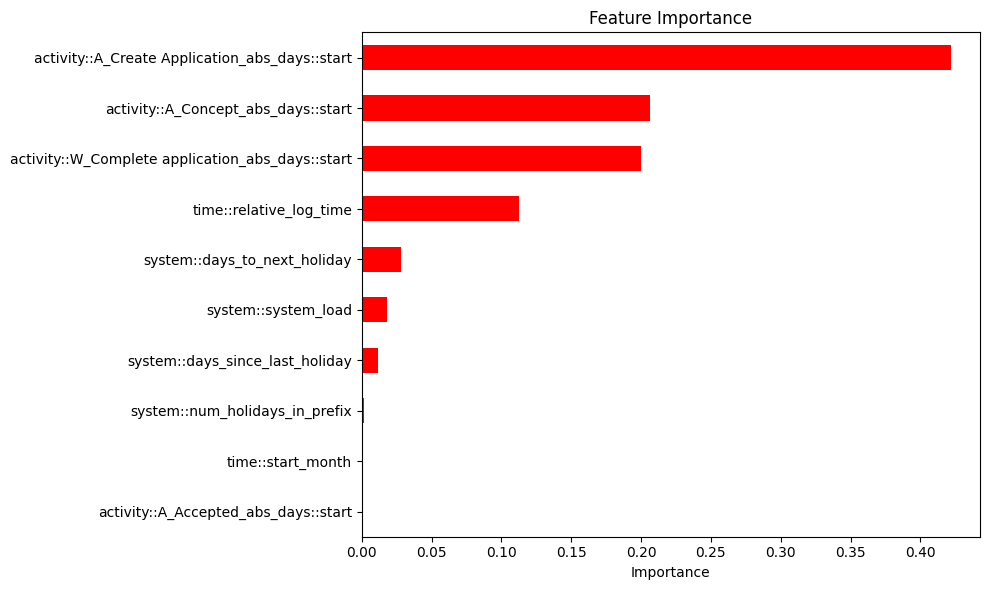

In [36]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances.sort_values().tail(10).plot(kind='barh', figsize=(10, 6), color='r')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [37]:
pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)

activity::A_Create Application_abs_days::start      0.421633
activity::A_Concept_abs_days::start                 0.206322
activity::W_Complete application_abs_days::start    0.199768
time::relative_log_time                             0.112588
system::days_to_next_holiday                        0.028213
system::system_load                                 0.017758
system::days_since_last_holiday                     0.011228
system::num_holidays_in_prefix                      0.001327
time::start_month                                   0.000984
activity::A_Accepted_abs_days::start                0.000024
dtype: float64

## Evaluation

### Prediction Quality

In [ ]:
plot_df = pd.DataFrame({
    'Actual (days)': y_test.values,
    'Predicted (days)': y_pred
})

reference_date = pd.Timestamp('2016-01-01', tz='UTC')
plot_df['Year'] = (reference_date + pd.to_timedelta(plot_df['Actual (days)'], unit='D')).dt.year.astype(str)

fig = px.scatter(
    plot_df,
    x='Actual (days)',
    y='Predicted (days)',
    color='Year',
    marginal_x='histogram',
    marginal_y='histogram',
    title='Actual vs Predicted Time to Loan Completion',
    opacity=0.6
)
fig.add_shape(
    type='line',
    x0=plot_df['Actual (days)'].min(),
    y0=plot_df['Actual (days)'].min(),
    x1=plot_df['Actual (days)'].max(),
    y1=plot_df['Actual (days)'].max(),
    line=dict(color='red', dash='dash', width=2)
)
fig.show()

In [ ]:
results_df = pd.DataFrame({
    'case_id': prefix_log_test['case::case:concept:name'].values,
    'prefix_length': prefix_log_test['meta::prefix_length'].values,
    'actual': y_test.values,
    'predicted': y_pred,
    'error': abs(y_test.values - y_pred)
})

mae_by_prefix = results_df.groupby('prefix_length').apply(
    lambda g: mean_absolute_error(g['actual'], g['predicted'])
).reset_index()
mae_by_prefix.columns = ['Prefix Length', 'MAE (days)']

fig = px.bar(
    mae_by_prefix,
    x='Prefix Length',
    y='MAE (days)',
    title='Average Prediction Error by Prefix Length'
)
fig.show()

In [ ]:
print(mae_by_prefix.to_string())

In [ ]:
print(f"Actual range: {results_df['actual'].min()} - {results_df['actual'].max()}")
print(f"Predicted range: {results_df['predicted'].min():.2f} - {results_df['predicted'].max():.2f}")
print(f"\nOutliers:")
print(results_df[results_df['error'] > 50][['case_id', 'prefix_length', 'actual', 'predicted', 'error']].sort_values('error', ascending=False).to_string())

In [ ]:
print(results_df[results_df["prefix_length"] == 11])

In [ ]:
print(results_df[abs(results_df["predicted"] - results_df["actual"]) > 1.0])

In [ ]:
results_df.groupby('prefix_length').size()

In [ ]:
print(mae_by_prefix)

In [ ]:
bpic17_outliers = results_df[results_df['error'] > 5]
display(prefix_log_test.iloc[bpic17_outliers.index])

# Results

## Ablation Study

### High-level and low-level Groups

In [38]:
high_level_variants, granular_variants = get_ablation_variants(X_train)

In [39]:
granular_variants

{'Raw sequence': ['activity::num_A_Create Application',
  'activity::num_A_Submitted',
  'activity::num_W_Handle leads',
  'activity::num_W_Complete application',
  'activity::num_A_Concept',
  'activity::num_A_Accepted',
  'activity::num_O_Create Offer',
  'activity::num_O_Created',
  'activity::num_O_Sent (mail and online)',
  'activity::num_W_Call after offers',
  'activity::num_A_Complete',
  'activity::num_W_Validate application',
  'activity::num_A_Validating',
  'activity::num_O_Returned',
  'activity::num_W_Call incomplete files',
  'activity::num_A_Incomplete',
  'activity::num_O_Accepted',
  'activity::num_A_Pending',
  'activity::num_A_Denied',
  'activity::num_O_Refused',
  'activity::num_O_Cancelled',
  'activity::num_A_Cancelled',
  'activity::num_O_Sent (online only)',
  'activity::num_W_Assess potential fraud',
  'activity::num_W_Personal Loan collection',
  'activity::num_W_Shortened completion ',
  'meta::prefix_length'],
 '+ Case attributes': ['activity::num_A_Create

In [40]:
high_level_variants

{'Raw sequence': ['activity::num_A_Create Application',
  'activity::num_A_Submitted',
  'activity::num_W_Handle leads',
  'activity::num_W_Complete application',
  'activity::num_A_Concept',
  'activity::num_A_Accepted',
  'activity::num_O_Create Offer',
  'activity::num_O_Created',
  'activity::num_O_Sent (mail and online)',
  'activity::num_W_Call after offers',
  'activity::num_A_Complete',
  'activity::num_W_Validate application',
  'activity::num_A_Validating',
  'activity::num_O_Returned',
  'activity::num_W_Call incomplete files',
  'activity::num_A_Incomplete',
  'activity::num_O_Accepted',
  'activity::num_A_Pending',
  'activity::num_A_Denied',
  'activity::num_O_Refused',
  'activity::num_O_Cancelled',
  'activity::num_A_Cancelled',
  'activity::num_O_Sent (online only)',
  'activity::num_W_Assess potential fraud',
  'activity::num_W_Personal Loan collection',
  'activity::num_W_Shortened completion ',
  'meta::prefix_length'],
 '+ Case-level features': ['activity::num_A_Cr

In [ ]:
bpic17_results_high = run_ablation(X_train, X_test, y_train, y_test, high_level_variants)

In [ ]:
bpic17_results_low = run_ablation(X_train, X_test, y_train, y_test, granular_variants)

In [ ]:
display(bpic17_results_high)
display(bpic17_results_low)

,Variant,MAE,RMSE,R2,N Features
0,Raw sequence,87.139,102.767,-0.027,27
1,+ Case-level features,88.247,106.091,-0.095,31
2,+ Event-level features,7.613,10.708,0.989,115
3,+ System-level features,0.323,3.070,0.999,121
4,Full pipeline,0.323,3.070,0.999,121


,Variant,MAE,RMSE,R2,N Features
0,Raw sequence,87.139,102.767,-0.027,27
1,+ Case attributes,88.247,106.091,-0.095,31
2,+ Event aggregations,60.773,77.792,0.411,55
3,+ Activity start times,7.637,10.712,0.989,107
4,+ Temporal features,7.613,10.708,0.989,115
5,+ System features,0.323,3.070,0.999,121
6,Full pipeline,0.323,3.070,0.999,121


In [ ]:
case_cols_bpic17 = [col for col in X_train.columns if col.startswith('case::')]
print("Case columns:", case_cols_bpic17)

rf_case_only_bpic17 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_case_only_bpic17.fit(X_train[case_cols_bpic17], y_train)

importances_bpic17 = pd.Series(rf_case_only_bpic17.feature_importances_, index=case_cols_bpic17)
print(importances_bpic17.sort_values(ascending=False))

y_pred_case_bpic17 = rf_case_only_bpic17.predict(X_test[case_cols_bpic17])
print("MAE case only:", mean_absolute_error(y_test, y_pred_case_bpic17))

Case columns: ['case::case:LoanGoal', 'case::case:ApplicationType', 'case::case:concept:name', 'case::case:RequestedAmount']
case::case:concept:name       0.711791
case::case:RequestedAmount    0.180330
case::case:LoanGoal           0.090001
case::case:ApplicationType    0.017878
dtype: float64
MAE case only: 93.66196938475125


In [ ]:

# BPIC17
print(f"Actual range: {y_test.min()} - {y_test.max()}")
print(f"Predicted range: {y_pred.min():.1f} - {y_pred.max():.1f}")

Actual range: 10 - 396
Predicted range: 10.0 - 395.9


### Single Feature Ablation Study

In [ ]:
variants = get_targeted_variants(X_train, 'activity::A_Create Application_abs_days::start')
results, importances = run_ablation_with_importance(X_train, X_test, y_train, y_test, variants)
display(results)
for name, importance in importances.items():
    print(f"\n{name}")
    display(importance)

,Variant,MAE,RMSE,R2,N Features
0,Full pipeline,0.323,3.070,0.999,121
1,Without relative_log_time,0.321,3.070,0.999,120
2,Without activity::A_Create Application_abs_days::start,0.318,3.048,0.999,120
3,Without both,0.323,3.119,0.999,119



Full pipeline


activity::A_Create Application_abs_days::start      0.429516
activity::W_Complete application_abs_days::start    0.202479
activity::A_Concept_abs_days::start                 0.195741
time::relative_log_time                             0.112587
system::days_to_next_holiday                        0.028188
system::system_load                                 0.017732
system::days_since_last_holiday                     0.011357
system::num_holidays_in_prefix                      0.001244
time::start_month                                   0.000982
event::concept:name_last                            0.000023
dtype: float64


Without relative_log_time


activity::A_Create Application_abs_days::start      0.504583
activity::A_Concept_abs_days::start                 0.226267
activity::W_Complete application_abs_days::start    0.209386
system::days_to_next_holiday                        0.027629
system::system_load                                 0.018113
system::days_since_last_holiday                     0.011372
system::num_holidays_in_prefix                      0.001459
time::start_month                                   0.001001
event::concept:name_last                            0.000024
activity::A_Complete_abs_days::start                0.000020
dtype: float64


Without activity::A_Create Application_abs_days::start


activity::A_Concept_abs_days::start                   0.432174
activity::W_Complete application_abs_days::start      0.393710
time::relative_log_time                               0.114163
system::days_to_next_holiday                          0.028682
system::system_load                                   0.017797
system::days_since_last_holiday                       0.011179
system::num_holidays_in_prefix                        0.001118
time::start_month                                     0.000983
activity::A_Accepted_abs_days::start                  0.000034
activity::O_Sent (mail and online)_abs_days::start    0.000025
dtype: float64


Without both


activity::A_Concept_abs_days::start                 0.491281
activity::W_Complete application_abs_days::start    0.449064
system::days_to_next_holiday                        0.027493
system::system_load                                 0.017780
system::days_since_last_holiday                     0.011798
system::num_holidays_in_prefix                      0.001386
time::start_month                                   0.001002
activity::A_Accepted_abs_days::start                0.000027
activity::O_Create Offer_abs_days::start            0.000025
event::concept:name_last                            0.000021
dtype: float64

In [ ]:
case_cols = [col for col in X_train.columns if col.startswith('case::')]
variants = {'Full pipeline': list(X_train.columns)}
for col in case_cols:
    variants[f'Without {col}'] = [c for c in X_train.columns if c != col]

results_case, importances_case = run_ablation_with_importance(X_train, X_test, y_train, y_test, variants)
display(results_case)

,Variant,MAE,RMSE,R2,N Features
0,Full pipeline,0.323,3.070,0.999,121
1,Without case::case:LoanGoal,0.321,3.092,0.999,120
2,Without case::case:ApplicationType,0.322,3.093,0.999,120
3,Without case::case:concept:name,0.323,3.153,0.999,120
4,Without case::case:RequestedAmount,0.320,3.089,0.999,120


In [ ]:
system_cols = [col for col in X_train.columns if col.startswith('system::')]
print(system_cols)
variants = {'Full pipeline': list(X_train.columns)}
for col in case_cols:
    variants[f'Without {col}'] = [c for c in X_train.columns if c != col]

results_case, importances_case = run_ablation_with_importance(X_train, X_test, y_train, y_test, variants)
display(results_case)

['system::number_of_unique_resources', 'system::num_holidays_in_prefix', 'system::days_to_next_holiday', 'system::days_since_last_holiday', 'system::system_load', 'system::duration_vs_period_avg']


,Variant,MAE,RMSE,R2,N Features
0,Full pipeline,0.323,3.070,0.999,121
1,Without case::case:LoanGoal,0.321,3.092,0.999,120
2,Without case::case:ApplicationType,0.322,3.093,0.999,120
3,Without case::case:concept:name,0.323,3.153,0.999,120
4,Without case::case:RequestedAmount,0.320,3.089,0.999,120


### Single Group Analysis

In [ ]:
run_group_only_analysis(X_train, X_test, y_train, y_test, 'case')
run_group_only_analysis(X_train, X_test, y_train, y_test, 'system')
run_group_only_analysis(X_train, X_test, y_train, y_test, 'event')

case columns: ['case::case:LoanGoal', 'case::case:ApplicationType', 'case::case:concept:name', 'case::case:RequestedAmount']
case::case:concept:name       0.711791
case::case:RequestedAmount    0.180330
case::case:LoanGoal           0.090001
case::case:ApplicationType    0.017878
dtype: float64
MAE case only: 93.66196938475125
system columns: ['system::number_of_unique_resources', 'system::num_holidays_in_prefix', 'system::days_to_next_holiday', 'system::days_since_last_holiday', 'system::system_load', 'system::duration_vs_period_avg']
system::days_since_last_holiday       0.587074
system::days_to_next_holiday          0.400766
system::system_load                   0.008014
system::num_holidays_in_prefix        0.003839
system::duration_vs_period_avg        0.000306
system::number_of_unique_resources    0.000002
dtype: float64
MAE system only: 0.19108551270304264
event columns: ['event::Action_last', 'event::org:resource_last', 'event::concept:name_last', 'event::EventOrigin_last', 'ev

(RandomForestRegressor(random_state=42),
 event::Action_last                   0.176934
 event::org:resource_last             0.275697
 event::concept:name_last             0.012073
 event::EventOrigin_last              0.000405
 event::EventID_last                  0.095320
 event::lifecycle:transition_last     0.000465
 event::FirstWithdrawalAmount_min     0.023628
 event::FirstWithdrawalAmount_max     0.022809
 event::FirstWithdrawalAmount_last    0.019399
 event::NumberOfTerms_min             0.023443
 event::NumberOfTerms_max             0.020896
 event::NumberOfTerms_last            0.019148
 event::Accepted_last                 0.007219
 event::MonthlyCost_min               0.028206
 event::MonthlyCost_max               0.030270
 event::MonthlyCost_last              0.024095
 event::Selected_last                 0.004716
 event::CreditScore_min               0.029178
 event::CreditScore_max               0.030277
 event::CreditScore_last              0.025216
 event::OfferedAmou

In [ ]:
results, importances = run_single_group_removal(X_train, X_test, y_train, y_test, 'case', exclude=['case::case:concept:name'])
display(results)

,Variant,MAE,RMSE,R2,N Features
0,Full pipeline,0.323,3.070,0.999,121
1,Without case::case:LoanGoal,0.321,3.092,0.999,120
2,Without case::case:ApplicationType,0.322,3.093,0.999,120
3,Without case::case:RequestedAmount,0.320,3.089,0.999,120


## Interpretation

### Target Analysis

In [ ]:
import plotly.express as px
A_pending_events = event_log[event_log["concept:name"] == "A_Pending"]
fig = px.histogram(A_pending_events, x="relative_case_time")
fig.add_vline(x=5, line_width=3, line_dash="dash", line_color="red")
fig.show()

In [ ]:
print(f"Cases: {event_log['case:concept:name'].nunique()}")
print(f"Events: {len(event_log)}")
print(f"Activities: {event_log['concept:name'].nunique()}")
print(f"Time span: {event_log['time:timestamp'].min()} to {event_log['time:timestamp'].max()}")
print(event_log.groupby('case:concept:name').size().describe())
print(event_log['concept:name'].unique())

Cases: 31509
Events: 1202267
Activities: 26
Time span: 2016-01-01 09:51:15.304000+00:00 to 2017-02-01 14:11:03.499000+00:00
count    31509.000000
mean        38.156305
std         16.715308
min         10.000000
25%         25.000000
50%         35.000000
75%         47.000000
max        180.000000
dtype: float64
['A_Create Application' 'A_Submitted' 'W_Handle leads'
 'W_Complete application' 'A_Concept' 'A_Accepted' 'O_Create Offer'
 'O_Created' 'O_Sent (mail and online)' 'W_Call after offers' 'A_Complete'
 'W_Validate application' 'A_Validating' 'O_Returned'
 'W_Call incomplete files' 'A_Incomplete' 'O_Accepted' 'A_Pending'
 'A_Denied' 'O_Refused' 'O_Cancelled' 'A_Cancelled' 'O_Sent (online only)'
 'W_Assess potential fraud' 'W_Personal Loan collection'
 'W_Shortened completion ']


### Outlier Analysis

In [ ]:
results_df = pd.DataFrame({
    'case_id': prefix_log_test['meta::case_id'].values,
    'prefix_length': prefix_log_test['meta::prefix_length'].values,
    'actual': y_test.values,
    'predicted': y_pred
})
results_df['error'] = abs(results_df['actual'] - results_df['predicted'])
print(results_df.sort_values('error', ascending=False).head(3))

                     case_id  prefix_length  actual  predicted   error
1046   Application_157155173             15     381     253.57  127.43
2957   Application_739325744             17     390     269.01  120.99
1829  Application_2041082181             16     157     131.47   25.53


In [ ]:
outlier_cases = ['Application_157155173', 'Application_739325744', 'Application_2041082181']
for case in outlier_cases:
    print(f"\n{case}")
    subset = event_log[event_log['case:concept:name'] == case]
    print(subset[['concept:name', 'lifecycle:transition', 'time:timestamp', 'relative_case_time', 'relative_log_time']].to_string())


=== Application_157155173 ===
                    concept:name lifecycle:transition                   time:timestamp  relative_case_time  relative_log_time
804359      A_Create Application             complete 2016-09-05 20:32:35.216000+00:00                   0                248
804360               A_Submitted             complete 2016-09-05 20:32:35.248000+00:00                   0                248
804361            W_Handle leads             schedule 2016-09-05 20:32:35.390000+00:00                   0                248
804362            W_Handle leads             withdraw 2016-09-05 20:33:17.175000+00:00                   0                248
804363    W_Complete application             schedule 2016-09-05 20:33:17.181000+00:00                   0                248
804364                 A_Concept             complete 2016-09-05 20:33:17.186000+00:00                   0                248
804365                A_Accepted             complete 2016-09-07 16:51:36.933000+00:00 

In [ ]:
# Check how CreditScore varies within cases in BPIC17
credit_score_variation = event_log.groupby('case:concept:name')['CreditScore'].nunique()
print("Cases with more than 1 unique CreditScore:", (credit_score_variation > 1).sum())
print("Cases with exactly 1 unique CreditScore:", (credit_score_variation == 1).sum())

Cases with more than 1 unique CreditScore: 0
Cases with exactly 1 unique CreditScore: 1


In [ ]:
credit_score_counts = event_log.groupby('case:concept:name')['CreditScore'].apply(
    lambda x: x.dropna().nunique()
)
print(credit_score_counts.value_counts())

CreditScore
1    26703
2     4806
Name: count, dtype: int64
